# Gridworld and Value Iteration

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader as web
import datetime as dt
from typing import Optional, Tuple

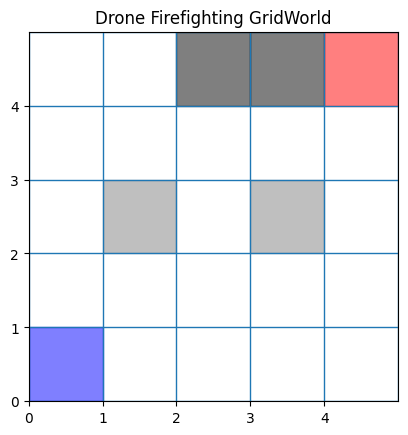

In [ ]:
GRID_SIZE=5
ACTIONS = ["north", "south","west","east","hover"]
ACTIONS_EFFECTS = {
    'north':(0,-1),
    'south': (0, 1),
    'east': (1, 0),
    'west': (-1, 0),
    'hover':(0,0)
}
class GridWorld(object):
  def __init__(self, world_spec:Optional[np.ndarray]=None):
    if world_spec is None:
      #s=Start, sf=Smoke Fumes, b=Boulder, g="Goal"
      self.world_spec = np.array(
          [['l','.','.','.','.'],
           ['.','.','sf','.','.'],
           ['.','.','.','.','b'],
           ['.','.','sf','.','b'],
           ['.','.','.','.','g']]
      )
    else:
      assert len(world_spec.shape)==2
      self.world_spec=world_spec
    assert len(np.where(self.world_spec=='g')[0])==1
    self.goal_cell=[x[0] for x in np.where(self.world_spec=='g')]

  def draw_grid(self):
    fig,ax=plt.subplots()
    for x in range(self.world_spec.shape[0]+1):
      ax.axhline(x,lw=1)
      ax.axvline(x,lw=1)
    for (x,y) in np.argwhere(self.world_spec=="sf"):
      ax.add_patch(plt.Rectangle((x,y),1,1,color="gray",alpha=0.5))
    for (x,y) in np.argwhere(self.world_spec=="b"):
      ax.add_patch(plt.Rectangle((x,y),1,1,color="black",alpha=0.5))
    for (x,y) in np.argwhere(self.world_spec=="l"):
      ax.add_patch(plt.Rectangle((x,y),1,1,color="blue",alpha=0.5))
    for (x,y) in np.argwhere(self.world_spec=="g"):
      ax.add_patch(plt.Rectangle((x,y),1,1,color="red",alpha=0.5))
    ax.set_xlim(0, GRID_SIZE)
    ax.set_ylim(0, GRID_SIZE)
    ax.set_xticks(range(GRID_SIZE))
    ax.set_yticks(range(GRID_SIZE))
    ax.set_aspect('equal')
    ax.set_title("Drone Firefighting GridWorld")

    # plt.gca().invert_yaxis()

    plt.show()


gwp = GridWorld()
gwp.draw_grid()

## Question 1: MDP and the state space

In [ ]:
class DroneMDP(GridWorld):
  def __init__(self,step_cost=-1,smoke_penalty=-10,boulder_penalty=-100,goal_reward=100):
    super().__init__()
    self.step_cost = step_cost
    self.smoke_penalty = smoke_penalty
    self.boulder_penalty = boulder_penalty
    self.goal_reward = goal_reward
    # self.gamma = gamma
    self.num_pos = GRID_SIZE**2
    self.num_actions = len(ACTIONS)
    self.num_states = self.num_pos * 2

    self.P = np.zeros((self.num_states, self.num_actions, self.num_states))
    self.R = np.zeros_like(self.P)
    self.build_mdp()
    # self.extract_local_submatrix()

  def state_to_index(self, x,y,water):
    pos_idx = y*GRID_SIZE + x
    return pos_idx*2 +water
  def index_to_state(self,state_idx):
    water = state_idx%2
    pos_idx = state_idx//2
    y = pos_idx//GRID_SIZE
    x = pos_idx%GRID_SIZE
    return x,y,water

  def in_bounds(self,x,y):
    return 0<=x<GRID_SIZE and 0<=y<GRID_SIZE
  def is_smoke(self,x,y):
    return self.world_spec[x,y]=="sf"
  def is_boulder(self,x,y):
    return self.world_spec[x,y]=="b"
  def is_goal(self,x,y):
    return self.world_spec[x,y]=="g"
  def is_lake(self,x,y):
    return self.world_spec[x,y]=="l"

  def build_mdp(self):
    for s in range(self.num_states):
      x,y,water = self.index_to_state(s)
      if self.is_boulder(x,y) or (self.is_goal(x,y) and water==1):
        self.P[s,:,s] = 1.0
        self.R[s,:,:] = 0
        continue
      for a_idx,action in enumerate(ACTIONS):
        if action=="hover":
          next_x,next_y = x,y
          next_water = water
          if self.is_lake(next_x,next_y):
            next_water = 1
          s_next = self.state_to_index(next_x,next_y,next_water)
          self.P[s,a_idx,s_next]=1.0
          self.R[s,a_idx,s_next]=-1
          continue
        if self.is_smoke(x,y):
          p_intended = 0.4
          p_stay = 0.4
        else:
          p_intended = 0.7
          p_stay = 0.1
        p_perp_1= 0.1
        p_perp_2= 0.1
        dx,dy = ACTIONS_EFFECTS[action]
        if action in ["north","south"]:
          perp_action_1 = "east"
          perp_action_2 = "west"
        else:
          # perp_action = ["north","south"]
          perp_action_1 = "north"
          perp_action_2 = "south"

        moves=[]
        moves.append((p_intended,dx,dy))
        pdx,pdy = ACTIONS_EFFECTS[perp_action_1]
        moves.append((p_perp_1,pdx,pdy))
        pdx2,pdy2 = ACTIONS_EFFECTS[perp_action_2]
        moves.append((p_perp_2,pdx2,pdy2))
        moves.append((p_stay,0,0))
        for prob, mx, my in moves:
          nx, ny = x+mx, y+my
          if not self.in_bounds(nx,ny):
            nx,ny = x,y
          next_water = water
          if self.is_lake(nx,ny):
            next_water = 1
          s_next = self.state_to_index(nx,ny,next_water)
          self.P[s,a_idx,s_next]+=prob
          reward = self.step_cost
          if self.is_smoke(nx,ny):
            reward += self.smoke_penalty
          if self.is_boulder(nx,ny):
            reward += self.boulder_penalty
          if self.is_goal(nx,ny) and next_water==1:
            reward += self.goal_reward

          self.R[s,a_idx,s_next]=reward

  def extract_local_submatrix(self,x,y,water=0):
    s = self.state_to_index(x, y,water)
    neighbour = []
    for dy in (-1,0,1):
      for dx in (-1,0,1):
        nx = x+dx
        ny = y+dy
        if 0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE:
          neighbour.append((nx,ny))
        else:
          neighbour.append((None))
    sub_P = np.zeros((self.num_actions,9))
    sub_R = np.zeros((self.num_actions,9))
    for a in range(self.num_actions):
      for i, cell in enumerate(neighbour):
        if cell is None:
          continue
        nx,ny = cell
        s_next = self.state_to_index(nx,ny,water)

        sub_P[a,i] = self.P[s,a,s_next]
        sub_R[a,i] = self.R[s,a,s_next]
    return sub_P, sub_R,neighbour

In [ ]:
mdp = DroneMDP()

sub_P, sub_R, cells = mdp.extract_local_submatrix(3,3,water=1)

print("Neighborhood (index order):")
print(cells)

print("\nTransition Sub-Matrix P:")
print(sub_P)

print("\nReward Sub-Matrix R:")
print(sub_R)

Neighborhood (index order):
[(2, 2), (3, 2), (4, 2), (2, 3), (3, 3), (4, 3), (2, 4), (3, 4), (4, 4)]

Transition Sub-Matrix P:
[[0.  0.7 0.  0.1 0.1 0.1 0.  0.  0. ]
 [0.  0.  0.  0.1 0.1 0.1 0.  0.7 0. ]
 [0.  0.1 0.  0.7 0.1 0.  0.  0.1 0. ]
 [0.  0.1 0.  0.  0.1 0.7 0.  0.1 0. ]
 [0.  0.  0.  0.  1.  0.  0.  0.  0. ]]

Reward Sub-Matrix R:
[[   0.  -11.    0.   -1.   -1.   -1.    0.    0.    0.]
 [   0.    0.    0.   -1.   -1.   -1.    0. -101.    0.]
 [   0.  -11.    0.   -1.   -1.    0.    0. -101.    0.]
 [   0.  -11.    0.    0.   -1.   -1.    0. -101.    0.]
 [   0.    0.    0.    0.   -1.    0.    0.    0.    0.]]


## Question 2: Two Phase Value Iteration

In [ ]:
def value_iteration(mdp, gamma=0.95, theta=1e-7):
  V = np.zeros(mdp.num_states)
  Error=[]
  while True:
    delta=0
    for s in range(mdp.num_states):
      v=V[s]
      Q_Sa = np.zeros(mdp.num_actions)
      for a in range(mdp.num_actions):
        Q_Sa[a] = np.sum(mdp.P[s,a,:]*(mdp.R[s,a,:]+gamma*V))
      V[s] = np.max(Q_Sa)
      delta = max(delta,np.abs(v-V[s]))
    Error.append(delta)
    if delta < theta:
      break

  policy = np.zeros(mdp.num_states,dtype=int)
  for s in range(mdp.num_states):
    Q_Sa = np.zeros(mdp.num_actions)
    for a in range(mdp.num_actions):
      Q_Sa[a] = np.sum(mdp.P[s,a,:]*(mdp.R[s,a,:]+gamma*V))
    policy[s] = np.argmax(Q_Sa)
  return V,policy,Error

def split_val(mdp,V):
  V_empty = np.zeros((GRID_SIZE,GRID_SIZE))
  V_full = np.zeros((GRID_SIZE,GRID_SIZE))
  for s in range(mdp.num_states):
    x,y,w = mdp.index_to_state(s)
    if w == 0:
      V_empty[y,x] = V[s]
    else:
      V_full[y,x] = V[s]
  return V_empty,V_full

def plot_value_func(V,title):
  plt.figure()
  plt.imshow(V,cmap='coolwarm',interpolation='nearest')
  plt.colorbar()
  plt.title(title)
  plt.gca().invert_yaxis()

  for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
      plt.text(j,i,f"{V[i,j]:.1f}", ha="center", va="center", color="white")
  plt.show()

ARROWS = {
    0: (0,-0.3),   # north
    1: (0,0.3),    # south
    2: (-0.3,0),   # west
    3: (0.3,0),    # east
    4: (0,0)       # hover
}

def plot_policy(mdp, policy,water_phase, title):
  plt.figure()
  plt.xlim(0, GRID_SIZE)
  plt.ylim(0, GRID_SIZE)
  # plt.gca().invert_yaxis()

  for x in range(GRID_SIZE+1):
      plt.axhline(x)
      plt.axvline(x)
  for (xx, yy) in np.argwhere(mdp.world_spec == "b"):
    plt.gca().add_patch(
        plt.Rectangle((xx, yy), 1, 1, color="black", alpha=0.4)
    )
  for (xx, yy) in np.argwhere(mdp.world_spec == "l"):
    plt.gca().add_patch(
        plt.Rectangle((xx, yy), 1, 1, color="blue", alpha=0.4)
    )
  for (xx, yy) in np.argwhere(mdp.world_spec == "g"):
    plt.gca().add_patch(
        plt.Rectangle((xx, yy), 1, 1, color="red", alpha=0.4)
    )
  for (xx, yy) in np.argwhere(mdp.world_spec == "sf"):
    plt.gca().add_patch(
        plt.Rectangle((xx, yy), 1, 1, color="gray", alpha=0.3)
    )
  for s in range(mdp.num_states):
      x,y,w = mdp.index_to_state(s)
      # if mdp.is_boulder(x,y) or (mdp.is_goal(x,y) and w==1):
      #   continue
      if w != water_phase:
        continue

      if mdp.is_boulder(x,y):
        continue

      if mdp.is_goal(x,y) and w==1:
        continue

      a = policy[s]
      dx,dy = ARROWS[a]

      plt.arrow(x+0.5, y+0.5, dx, dy,
                  head_width=0.1, head_length=0.1,
                  fc='r', ec='r')

  plt.title(title)
  plt.show()

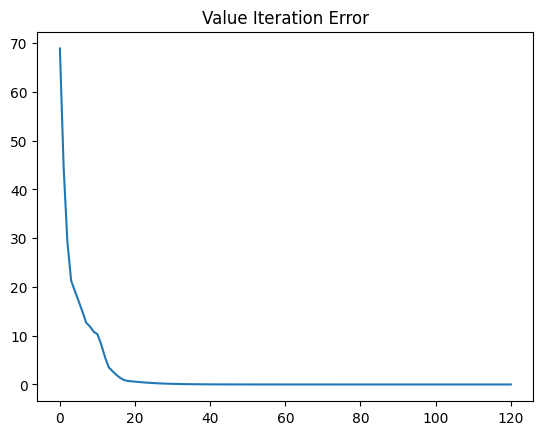

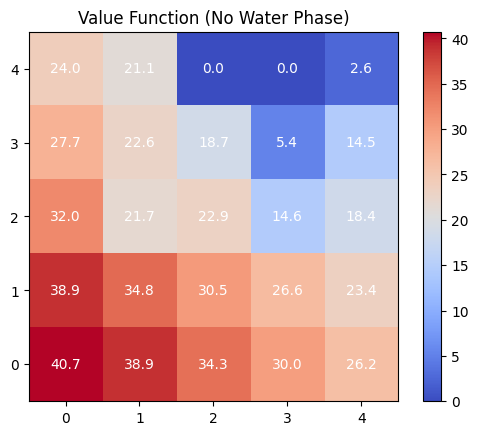

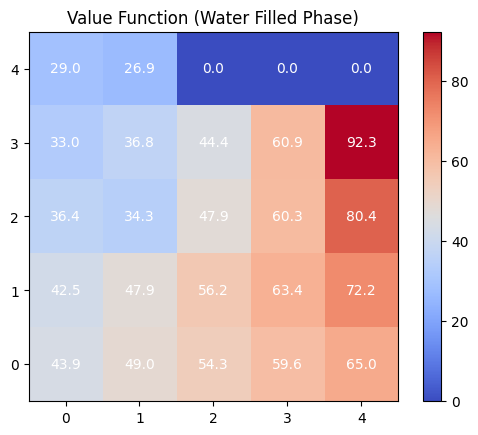

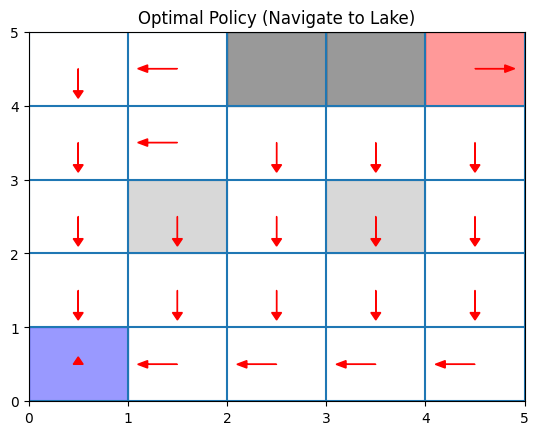

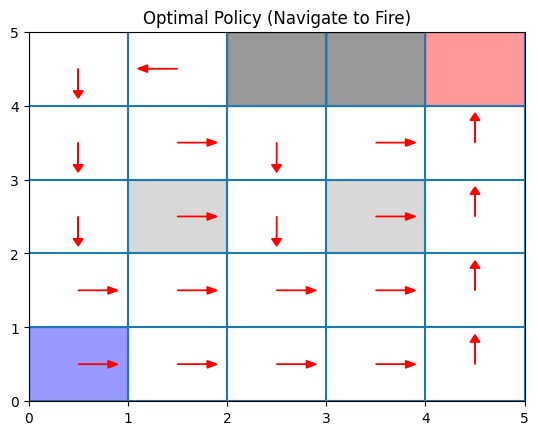

In [ ]:
mdp = DroneMDP()

V, policy,err = value_iteration(mdp)
V_empty, V_full = split_val(mdp, V)
plt.plot(err)
plt.title("Value Iteration Error")
plt.show()
plot_value_func(V_empty, "Value Function (No Water Phase)")
plot_value_func(V_full,  "Value Function (Water Filled Phase)")

plot_policy(mdp, policy, water_phase=0,
            title="Optimal Policy (Navigate to Lake)")

plot_policy(mdp, policy, water_phase=1,
            title="Optimal Policy (Navigate to Fire)")

In [ ]:
s = mdp.state_to_index(4,4,0)

for a in range(mdp.num_actions):
    q = np.sum(mdp.P[s,a,:] * (mdp.R[s,a,:] + 0.95*V))
    print(ACTIONS[a], q)

north -0.8355749893720614
south -8.75470300299637
west -69.12026366571912
east 2.626078443061475
hover 1.494774441115145


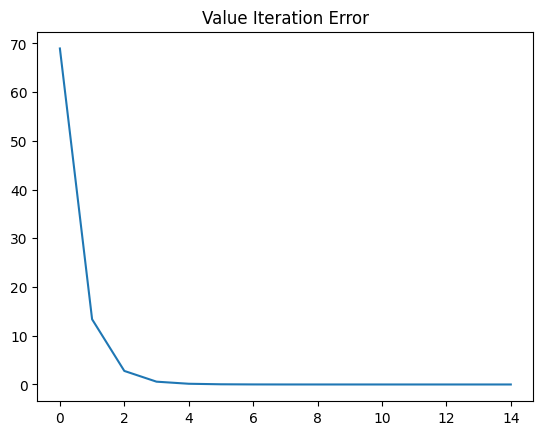

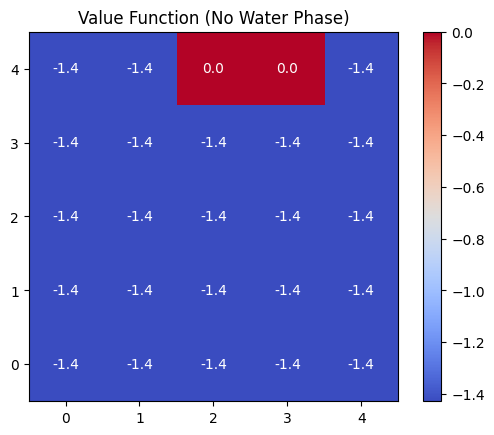

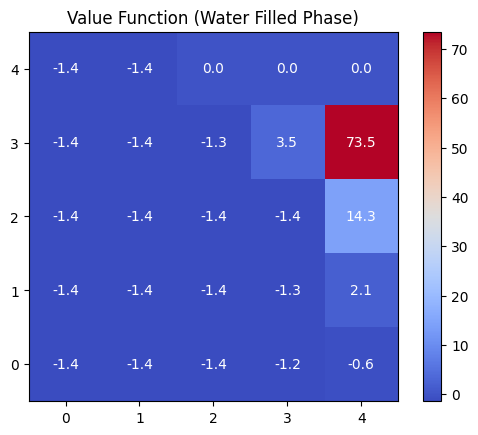

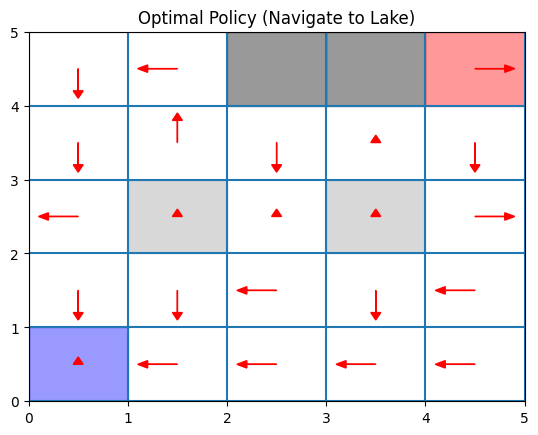

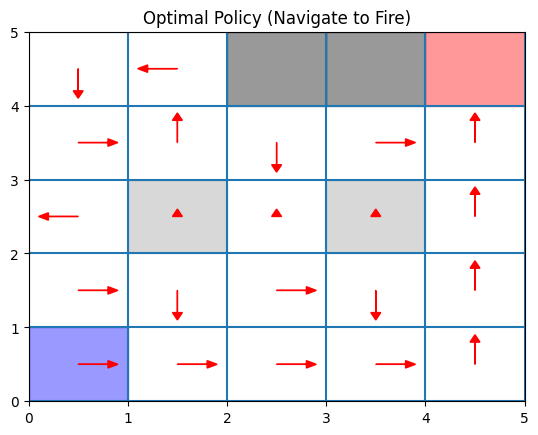

In [ ]:
mdp = DroneMDP()

V, policy,err = value_iteration(mdp, gamma = 0.3)
V_empty, V_full = split_val(mdp, V)
plt.plot(err)
plt.title("Value Iteration Error")
plt.show()
plot_value_func(V_empty, "Value Function (No Water Phase)")
plot_value_func(V_full,  "Value Function (Water Filled Phase)")

plot_policy(mdp, policy, water_phase=0,
            title="Optimal Policy (Navigate to Lake)")

plot_policy(mdp, policy, water_phase=1,
            title="Optimal Policy (Navigate to Fire)")

In [ ]:
s = mdp.state_to_index(4,2,0)

for a in range(mdp.num_actions):
    q = np.sum(mdp.P[s,a,:] * (mdp.R[s,a,:] + 0.95*V))
    print(ACTIONS[a], q)

north -3.357141835594485
south -3.357142827300541
west -9.357142690838732
east -2.3571426549740226
hover -2.3571427864340393


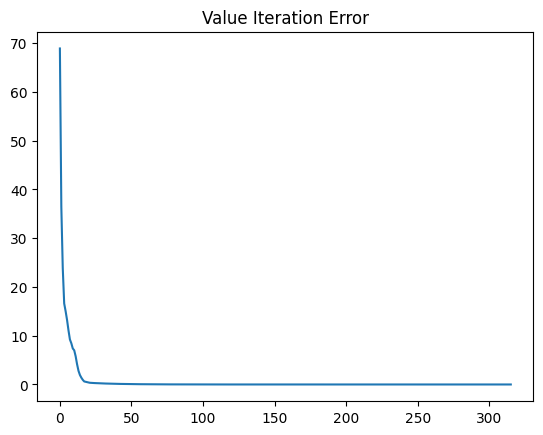

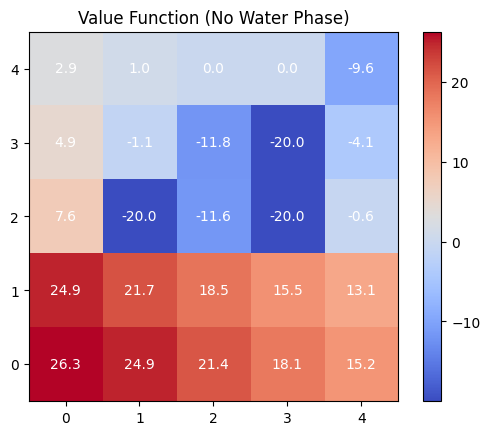

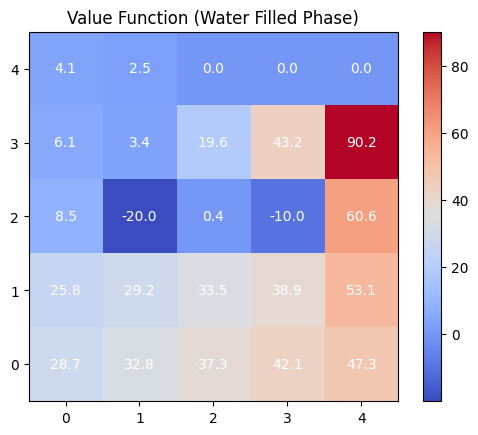

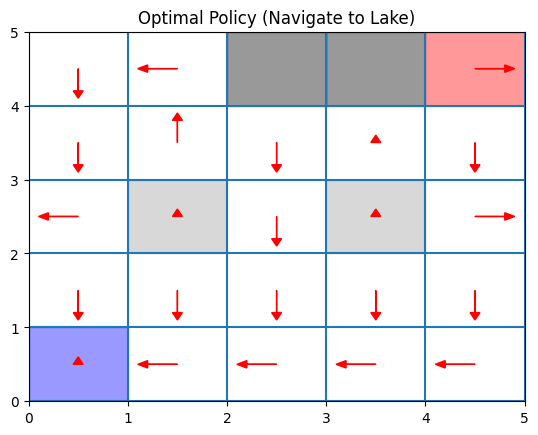

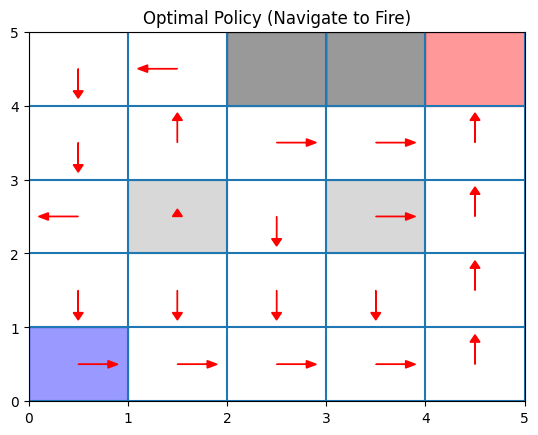

In [ ]:
mdp = DroneMDP(smoke_penalty=-90)

V, policy,err = value_iteration(mdp, gamma = 0.95)
V_empty, V_full = split_val(mdp, V)
plt.plot(err)
plt.title("Value Iteration Error")
plt.show()
plot_value_func(V_empty, "Value Function (No Water Phase)")
plot_value_func(V_full,  "Value Function (Water Filled Phase)")

plot_policy(mdp, policy, water_phase=0,
            title="Optimal Policy (Navigate to Lake)")

plot_policy(mdp, policy, water_phase=1,
            title="Optimal Policy (Navigate to Fire)")

In [ ]:
class DroneMDP_changed(GridWorld):
  def __init__(self,step_cost=-1,smoke_penalty=-10,boulder_penalty=-100,goal_reward=100):
    super().__init__()
    self.step_cost = step_cost
    self.smoke_penalty = smoke_penalty
    self.boulder_penalty = boulder_penalty
    self.goal_reward = goal_reward
    # self.gamma = gamma
    self.num_pos = GRID_SIZE**2
    self.num_actions = len(ACTIONS)
    self.num_states = self.num_pos * 2

    self.P = np.zeros((self.num_states, self.num_actions, self.num_states))
    self.R = np.zeros_like(self.P)
    self.build_mdp()
    # self.extract_local_submatrix() # Removed: This method expects arguments and should not be called here.

  def state_to_index(self, x,y,water):
    pos_idx = y*GRID_SIZE + x
    return pos_idx*2 +water
  def index_to_state(self,state_idx):
    water = state_idx%2
    pos_idx = state_idx//2
    y = pos_idx//GRID_SIZE
    x = pos_idx%GRID_SIZE
    return x,y,water

  def in_bounds(self,x,y):
    return 0<=x<GRID_SIZE and 0<=y<GRID_SIZE
  def is_smoke(self,x,y):
    return self.world_spec[x,y]=="sf"
  def is_boulder(self,x,y):
    return self.world_spec[x,y]=="b"
  def is_goal(self,x,y):
    return self.world_spec[x,y]=="g"
  def is_lake(self,x,y):
    return self.world_spec[x,y]=="l"

  def build_mdp(self):
    for s in range(self.num_states):
      x,y,water = self.index_to_state(s)
      if self.is_boulder(x,y) or (self.is_goal(x,y) and water==1):
        self.P[s,:,s] = 1.0
        self.R[s,:,:] = 0
        continue
      for a_idx,action in enumerate(ACTIONS):
        if action=="hover":
          next_x,next_y = x,y
          next_water = water
          if self.is_lake(next_x,next_y):
            next_water = 1
          s_next = self.state_to_index(next_x,next_y,next_water)
          self.P[s,a_idx,s_next]=1.0
          self.R[s,a_idx,s_next]=-1
          continue
        # if self.is_smoke(x,y):
        #   p_intended = 0.4
        #   p_stay = 0.4
        # else:
        #   p_intended = 0.7
        #   p_stay = 0.1
        p_intended = 0.4
        p_perp_1= 0.25
        p_perp_2= 0.25
        p_stay = 1-p_intended-p_perp_1-p_perp_2
        dx,dy = ACTIONS_EFFECTS[action]
        if action in ["north","south"]:
          perp_action_1 = "east"
          perp_action_2 = "west"
        else:
          # perp_action = ["north","south"]
          perp_action_1 = "north"
          perp_action_2 = "south"

        moves=[]
        moves.append((p_intended,dx,dy))
        pdx,pdy = ACTIONS_EFFECTS[perp_action_1]
        moves.append((p_perp_1,pdx,pdy))
        pdx2,pdy2 = ACTIONS_EFFECTS[perp_action_2]
        moves.append((p_perp_2,pdx2,pdy2))
        moves.append((p_stay,0,0))
        for prob, mx, my in moves:
          nx, ny = x+mx, y+my
          if not self.in_bounds(nx,ny):
            nx,ny = x,y
          next_water = water
          if self.is_lake(nx,ny):
            next_water = 1
          s_next = self.state_to_index(nx,ny,next_water)
          self.P[s,a_idx,s_next]+=prob
          reward = self.step_cost
          if self.is_smoke(nx,ny):
            reward += self.smoke_penalty
          if self.is_boulder(nx,ny):
            reward += self.boulder_penalty
          if self.is_goal(nx,ny) and next_water==1:
            reward += self.goal_reward

          self.R[s,a_idx,s_next]=reward

  def extract_local_submatrix(self,x,y,water=0):
    s = self.state_to_index(x, y,water)
    neighbour = []
    for dy in (-1,0,1):
      for dx in (-1,0,1):
        nx = x+dx
        ny = y+dy
        if 0 <= nx < GRID_SIZE and 0 <= ny < GRID_SIZE:
          neighbour.append((nx,ny))
        else:
          neighbour.append((None))
    sub_P = np.zeros((self.num_actions,9))
    sub_R = np.zeros((self.num_actions,9))
    for a in range(self.num_actions):
      for i, cell in enumerate(neighbour):
        if cell is None:
          continue
        nx,ny = cell
        s_next = self.state_to_index(nx,ny,water)

        sub_P[a,i] = self.P[s,a,s_next]
        sub_R[a,i] = self.R[s,a,s_next]
    return sub_P, sub_R,neighbour

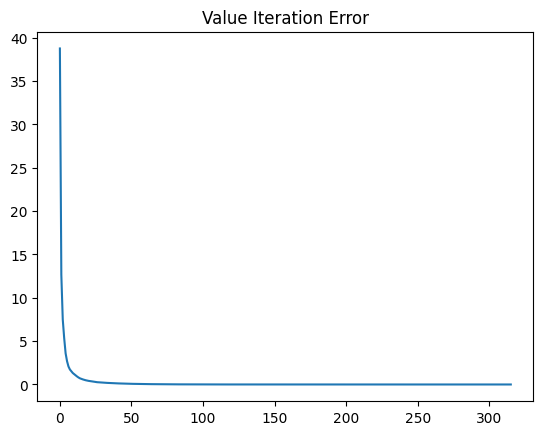

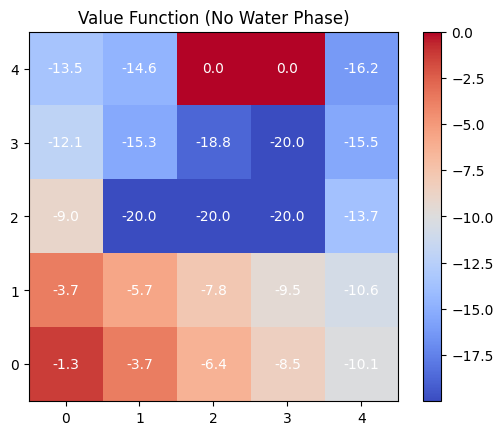

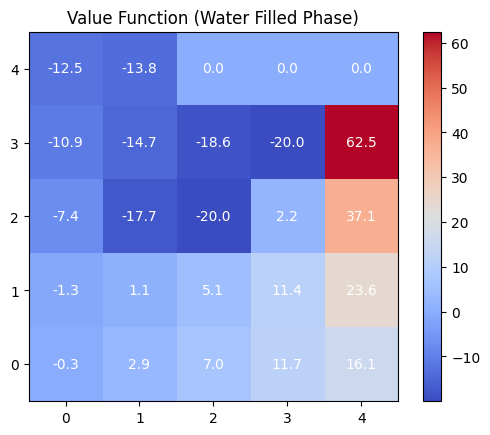

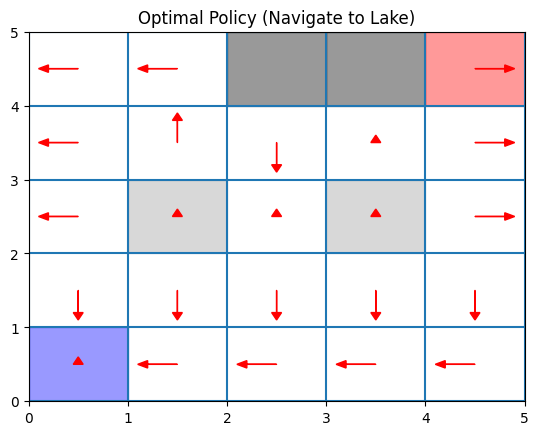

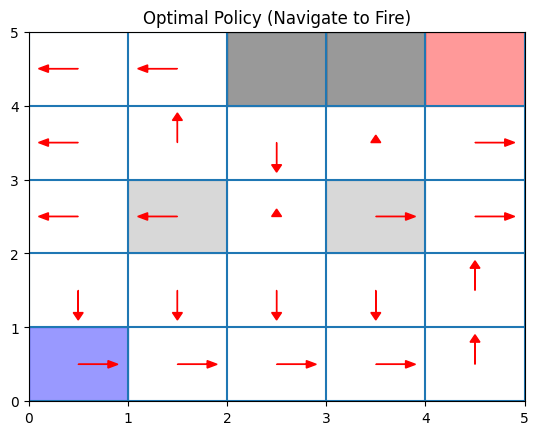

In [ ]:
mdp = DroneMDP_changed(smoke_penalty=-90)
V, policy,err = value_iteration(mdp, gamma = 0.95)
V_empty, V_full = split_val(mdp, V)
plt.plot(err)
plt.title("Value Iteration Error")
plt.show()
plot_value_func(V_empty, "Value Function (No Water Phase)")
plot_value_func(V_full,  "Value Function (Water Filled Phase)")

plot_policy(mdp, policy, water_phase=0,
            title="Optimal Policy (Navigate to Lake)")

plot_policy(mdp, policy, water_phase=1,
            title="Optimal Policy (Navigate to Fire)")

In [ ]:
s = mdp.state_to_index(4,4,0)

for a in range(mdp.num_actions):
    q = np.sum(mdp.P[s,a,:] * (mdp.R[s,a,:] + 0.95*V))
    print(ACTIONS[a], q)

north -37.27633725871903
south -37.57651772471584
west -50.07360138852467
east -16.247744175039784
hover -16.435356966287795
